Znajdź pasażerów 1 klasy, kobiety, które przeżyły
Oblicz średni wiek i średnią cenę biletu dla tej grupy
Porównaj z mężczyznami z 3 klasy którzy nie przeżyli
Stwórz wykres porównawczy (barplot)

In [1]:
import sqlite3
import pandas as pd

url ='https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)

conn = sqlite3.connect('titanic.db')
titanic.to_sql('passengers', conn, if_exists='replace', index=False)


891

In [5]:
# conn.execute("CREATE INDEX idx_survived ON passengers(Survived)")
# conn.execute("CREATE INDEX idx_pclass ON passengers(Pclass)")
# conn.execute("CREATE INDEX idx_sex ON passengers(Sex)")

query1 = """
SELECT
Sex,
Pclass,
COUNT(*) AS total_passengers,
SUM(Survived) AS survived,
ROUND(AVG(Survived) * 100, 1) AS survival_rate
FROM passengers
GROUP BY Sex, Pclass
ORDER BY Sex, Pclass
"""

survival_analysis = pd.read_sql_query(query1, conn)
print("Przeżywalność: płeć x klasa")
print(survival_analysis)

Przeżywalność: płeć x klasa
      Sex  Pclass  total_passengers  survived  survival_rate
0  female       1                94        91           96.8
1  female       2                76        70           92.1
2  female       3               144        72           50.0
3    male       1               122        45           36.9
4    male       2               108        17           15.7
5    male       3               347        47           13.5


In [10]:
query_sur_ladies = """
SELECT
Age,
Fare
FROM passengers
WHERE Pclass = 1 AND Sex='female' AND Survived = 1
"""
sur_ladies = pd.read_sql_query(query_sur_ladies, conn)

print(sur_ladies)

     Age      Fare
0   38.0   71.2833
1   35.0   53.1000
2   58.0   26.5500
3    NaN  146.5208
4   49.0   76.7292
..   ...       ...
86  45.0  164.8667
87  48.0   25.9292
88  47.0   52.5542
89  56.0   83.1583
90  19.0   30.0000

[91 rows x 2 columns]


In [21]:
query_dead_gents = """
SELECT
Age,
Fare
FROM passengers
WHERE Pclass = 3 AND Sex='male' AND Survived = 0
"""
dead_gents = pd.read_sql_query(query_dead_gents, conn)

conn.close()

print(dead_gents)

      Age     Fare
0    22.0   7.2500
1    35.0   8.0500
2     NaN   8.4583
3     2.0  21.0750
4    20.0   8.0500
..    ...      ...
295  19.0   7.8958
296   NaN   7.8958
297  33.0   7.8958
298  25.0   7.0500
299  32.0   7.7500

[300 rows x 2 columns]


In [22]:
stats_ladies = sur_ladies[['Age', 'Fare']].mean()
stats_gents = dead_gents[['Age', 'Fare']].mean()
print(stats_ladies)
print(stats_gents)

Age      34.939024
Fare    105.978159
dtype: float64
Age     27.255814
Fare    12.204469
dtype: float64


C:\Users\Maciek\AppData\Local\Temp\ipykernel_6224\1690413525.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Grupa', y='Age', data=df_plot, estimator='mean', errorbar=None, palette='muted')


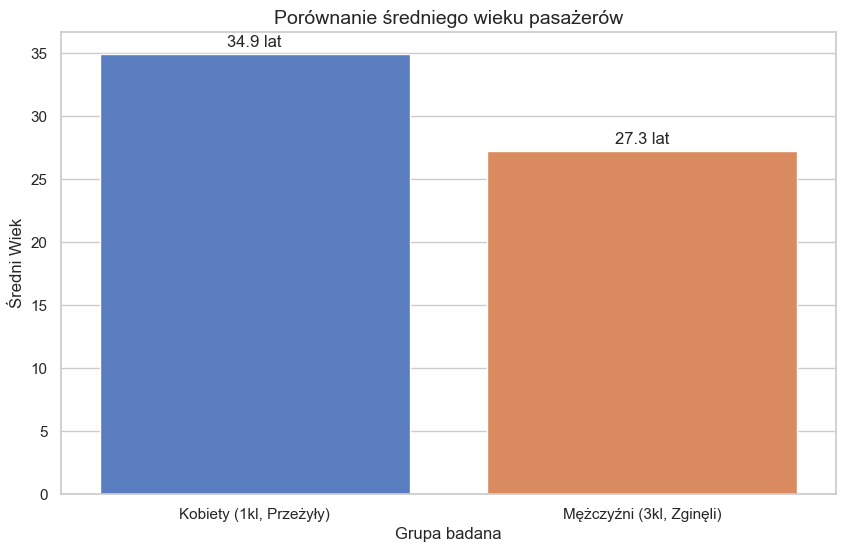

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sur_ladies['Grupa'] = 'Kobiety (1kl, Przeżyły)'
dead_gents['Grupa'] = 'Mężczyźni (3kl, Zginęli)'

df_plot = pd.concat([sur_ladies, dead_gents], ignore_index=True)

# 4. Tworzenie wykresu barplot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Wykres porównujący średni wiek
ax = sns.barplot(x='Grupa', y='Age', data=df_plot, estimator='mean', errorbar=None, palette='muted')

# Dodanie kosmetyki
plt.title('Porównanie średniego wieku pasażerów', fontsize=14)
plt.ylabel('Średni Wiek', fontsize=12)
plt.xlabel('Grupa badana', fontsize=12)

# Dodanie etykiet z wartościami nad słupkami
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f lat', padding=3)

plt.show()